# Repaso Final - Data Science
Este notebook es un repaso integrador para el curso de Data Science. Sigue cada pregunta y resuelve en las celdas correspondientes.

### Instrucciones:
Responde cada pregunta en una celda nueva, justificando tus decisiones y comentando el código cuando sea necesario.

**1. Importa las librerías necesarias (numpy, pandas, matplotlib, seaborn, scikit-learn, etc.).**

In [15]:
!pip install rapidfuzz

In [16]:
# Tu código aquí
import re

import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz

import matplotlib.pyplot as plt
import seaborn as sns

**2. Carga el dataset (`salary_survey.xlsx`) y muestra las primeras 5 filas.**

In [17]:
# Tu código aquí

df = pd.read_excel('salary_survey.xlsx')
df.head()

,Timestamp,How old are you?,What industry do you work in?,Job title,"If your job title needs additional context, please clarify here:","What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)","How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",Please indicate the currency,"If ""Other,"" please indicate the currency here:","If your income needs additional context, please provide it here:",What country do you work in?,"If you're in the U.S., what state do you work in?",What city do you work in?,How many years of professional work experience do you have overall?,How many years of professional work experience do you have in your field?,What is your highest level of education completed?,What is your gender?,What is your race? (Choose all that apply.)
0,2021-04-27 11:02:09.743,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,55000,0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,2021-04-27 11:02:21.562,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,54600,4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,2021-04-27 11:02:38.125,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,34000,NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,2021-04-27 11:02:40.643,25-34,Nonprofits,Program Manager,NaN,62000,3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,2021-04-27 11:02:41.793,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,60000,7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


In [18]:
rename_dict = {
    'Timestamp': 'timestamp',
    'How old are you?': 'age',
    'What industry do you work in?': 'industry',
    'Job title': 'job_title',
    'If your job title needs additional context, please clarify here:': 'job_context',
    "What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)": 'annual_salary',
    'How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.': 'extra_compensation',
    'Please indicate the currency': 'currency',
    'If "Other," please indicate the currency here: ': 'other_currency',
    'If your income needs additional context, please provide it here:': 'income_context',
    'What country do you work in?': 'country',
    "If you're in the U.S., what state do you work in?": 'state_us',
    'What city do you work in?': 'city',
    'How many years of professional work experience do you have overall?': 'experience_total',
    'How many years of professional work experience do you have in your field?': 'experience_field',
    'What is your highest level of education completed?': 'education_level',
    'What is your gender?': 'gender',
    'What is your race? (Choose all that apply.)': 'race'
}

df.rename(columns=rename_dict, inplace=True)

df.head()

,timestamp,age,industry,job_title,job_context,annual_salary,extra_compensation,currency,other_currency,income_context,country,state_us,city,experience_total,experience_field,education_level,gender,race
0,2021-04-27 11:02:09.743,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,55000,0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,2021-04-27 11:02:21.562,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,54600,4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,2021-04-27 11:02:38.125,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,34000,NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,2021-04-27 11:02:40.643,25-34,Nonprofits,Program Manager,NaN,62000,3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,2021-04-27 11:02:41.793,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,60000,7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28149 entries, 0 to 28148
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           28149 non-null  datetime64[ns]
 1   age                 28149 non-null  object        
 2   industry            28071 non-null  object        
 3   job_title           28147 non-null  object        
 4   job_context         7280 non-null   object        
 5   annual_salary       28149 non-null  int64         
 6   extra_compensation  20813 non-null  float64       
 7   currency            28149 non-null  object        
 8   other_currency      214 non-null    object        
 9   income_context      3049 non-null   object        
 10  country             28149 non-null  object        
 11  state_us            23099 non-null  object        
 12  city                28067 non-null  object        
 13  experience_total    28149 non-null  object    

**3. Limpieza y preparación de datos:**
- Revisa valores nulos.
- Normaliza encabezados (sin espacios, minúsculas).
- Convierte columnas numéricas a tipo numérico.
- Realiza cualquier limpieza necesaria para trabajar con los datos

In [20]:
df.isnull().sum()

,0
timestamp,0
age,0
industry,78
job_title,2
job_context,20869
annual_salary,0
extra_compensation,7336
currency,0
other_currency,27935
income_context,25100


In [21]:
df.dropna(subset=[
    'job_title',
    'industry',
    'city'
], inplace=True)

df.drop(columns=[
    'other_currency','state_us', 'income_context', 'job_context', 'timestamp', 'city','experience_field'
], inplace=True)

df['extra_compensation'] = df['extra_compensation'].fillna(0)
df['education_level'] = df['education_level'].fillna('College degree')
df['gender'] = df['gender'].fillna('Woman')
df['race'] = df['race'].fillna('White')


In [22]:
# Tu código aquí
#df.isnull().sum().sort_values(ascending=False).to_frame(name="missing_values").T
df.isnull().sum()

,0
age,0
industry,0
job_title,0
annual_salary,0
extra_compensation,0
currency,0
country,0
experience_total,0
education_level,0
gender,0


# Estandarizacion de las variables

<Axes: >

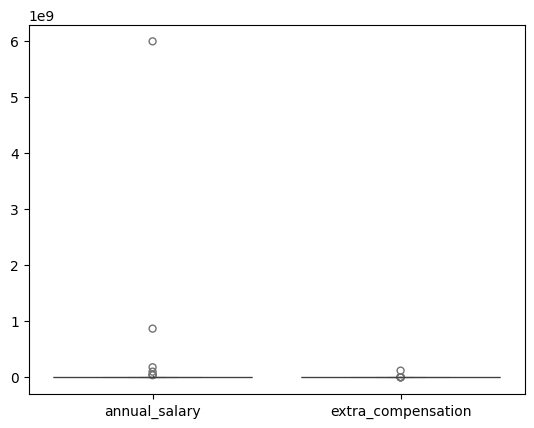

In [23]:
sns.boxenplot(df.select_dtypes('number'))

In [24]:

def replace_outliers_with_mode(df, columns):
    df = df.copy()
    for col in columns:
        if col not in df.columns:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        moda = df[col].mode()[0]
        df.loc[(df[col] < lower) | (df[col] > upper), col] = moda
    return df


In [25]:
df = replace_outliers_with_mode(df, ['annual_salary', 'extra_compensation'])

<Axes: >

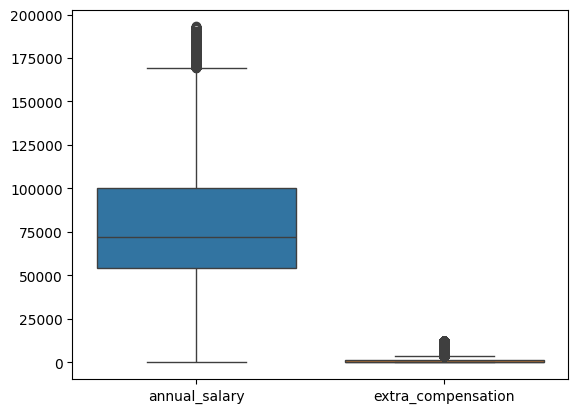

In [27]:
sns.boxplot(df.select_dtypes('number'))


In [28]:
df.age.value_counts()

,count
age,
25-34,12628
35-44,9854
45-54,3175
18-24,1239
55-64,986
65 or over,95
under 18,12


In [29]:
df.industry.value_counts()

,count
industry,
Computing or Tech,4706
Education (Higher Education),2453
Nonprofits,2416
Health care,1898
Government and Public Administration,1888
...,...
Learning and Development,1
Data Analytics,1
Luxury Fashion,1


In [30]:
def selector_clases(cantidad_clases, columna):

    words =  []

    for frase in df[columna].values:
        palabras = frase.split(' ')
        for palabra in palabras:
            palabra = palabra.strip().replace('or','').replace('and','').lower()
            palabra = re.sub(r'[^a-zA-Z]', '', palabra)
            words.append(palabra if len(palabra) > 2 else '')

    return pd.Series(words).value_counts().iloc[1:cantidad_clases].index


In [31]:
def clasificar_fase(palabra, clases,umbral):
    best_match, score, _ = process.extractOne(
        palabra, clases, scorer=fuzz.ratio
    )

    if score >= umbral:
        return best_match
    else:
        return 'otra'

In [32]:
clases = selector_clases(35,'industry')

df['industry'] = df.industry.apply(lambda x: clasificar_fase(x, clases, 45))



In [33]:
categorias = df.job_title.value_counts().iloc[:35].index.str.lower()

df['job_title'] = df.job_title.apply(lambda x: clasificar_fase(x, categorias, 35))

In [34]:
clases = df.country.str.replace(r'[^a-zA-Z ]', '', regex=True)\
.str.lower().str.strip().value_counts().iloc[0:40].index

clases = pd.Series(clases)

resultado = clases.apply(
    lambda x: process.extractOne(x, ['united states'])[0]
    if process.extractOne(x, ['united states'])[1] > 40
    else x
).unique()

resultado

array(['united states', 'canada', 'australia', 'germany', 'england',
       'new zealand', 'france', 'switzerland', 'belgium', 'japan',
       'america', 'denmark', 'singapore', 'south africa', 'finland',
       'norway', 'malaysia', 'brazil', 'philippines', 'poland', 'china'],
      dtype=object)

In [35]:
df.country = df.country.apply( lambda x: clasificar_fase(x.lower().strip().replace('.',''), resultado, 40))

In [511]:
clases = selector_clases(15, 'race')[1:].delete(2).delete(3).delete(7)[:7]
clases
df.race = df.race.apply(lambda x: clasificar_fase(x, clases, 20))

In [36]:
df.head()

,age,industry,job_title,annual_salary,extra_compensation,currency,country,experience_total,education_level,gender,race
0,25-34,construction,administrative assistant,55000,0.0,USD,united states,5-7 years,Master's degree,Woman,White
1,25-34,computing,operations manager,54600,4000.0,GBP,united states,8 - 10 years,College degree,Non-binary,White
2,25-34,accounting,marketing manager,34000,0.0,USD,otra,2 - 4 years,College degree,Woman,White
3,25-34,nonprofits,program manager,62000,3000.0,USD,australia,8 - 10 years,College degree,Woman,White
4,25-34,accounting,account manager,60000,7000.0,USD,otra,8 - 10 years,College degree,Woman,White


**4. EDA:**
- Distribución de edades.
- Industrias con mayores salarios promedio.
- Diferencia salarial entre géneros.
- Salario por nivel educativo.

<Axes: ylabel='age'>

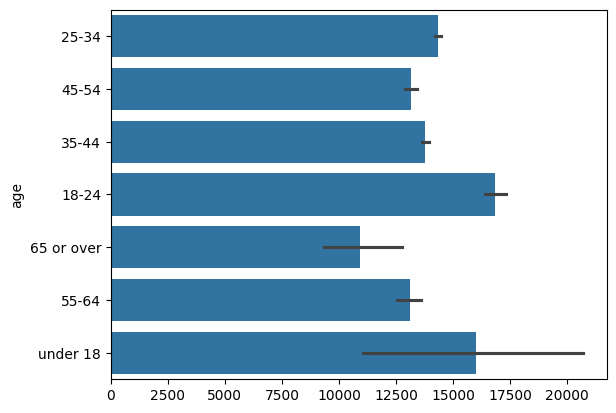

In [39]:
# Tu código aquí
#Distribución de edades.


sns.barplot(df.age)

In [40]:
salarios_promedio = (
    df.groupby('industry')['annual_salary']
    .mean()
    .sort_values(ascending=False)
)

salarios_promedio.round(2).iloc[:10]

,annual_salary
industry,
computing,102300.39
consulting,90568.65
manufacturing,89206.09
property,87400.00
tech,87310.01
law,86364.01
telecommunications,83186.76
finance,82717.13
insurance,80360.25


In [515]:
#Diferencia salarial entre géneros.

df.groupby(['gender'])['annual_salary'].mean().round(2).sort_values(ascending=True)


,annual_salary
gender,
Non-binary,66197.34
Woman,77939.37
Other or prefer not to answer,80427.25
Prefer not to answer,88000.00
Man,90481.20


In [41]:
#Salario por nivel educativo.

df.groupby(['education_level'])['annual_salary'].mean().round(2).sort_values(ascending=True)

,annual_salary
education_level,
High School,64948.18
Some college,68445.53
College degree,78131.42
Master's degree,82494.25
PhD,93136.15
"Professional degree (MD, JD, etc.)",96319.92


**5. Estadística:**
- Media, mediana, desviación estándar de salarios.
- Prueba de hipótesis (¿diferencia significativa del sueldo entre géneros?).

In [517]:
# Tu código aquí

**6. Visualización:**
- Barra de los 5 títulos mejor pagados.
- Heatmap de correlaciones.

In [518]:
# Tu código aquí


**7. Machine Learning:**
Entrena un modelo capaz de predecir el salario de una persona.
- Crear variable objetivo (alto vs. bajo salario).
- Split train/test.
- Eleccion del modelo .
- Evaluar modelo.

In [42]:
# Tu código aquí

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


In [43]:
y = df['annual_salary']

X = pd.get_dummies(df.drop(columns=['annual_salary']), dtype=float)

In [44]:
X.shape

(27989, 181)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

In [46]:
pipelines = {
    'LinearRegression': Pipeline([('scaler', scaler), ('model', LinearRegression())]),
    'RandomForest': Pipeline([('model', RandomForestRegressor(random_state=42))])
}

In [47]:
# hiper param de la grilla

param_grid = {
    'LinearRegression': {},
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    }
}

In [544]:
#grid search par acada modelo

results = []

for name, pipeline in pipelines.items():
    print(f"Entrenando {name}...")
    grid = GridSearchCV(pipeline, param_grid[name], cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'model': name,
        'best_params': grid.best_params_,
        'r2_train_cv': grid.best_score_,
        'r2_test': r2,
        'mse_test': mse
    })

Entrenando LinearRegression...
Entrenando RandomForest...


In [546]:
results_df = pd.DataFrame(results).sort_values(by='r2_test', ascending=False)
results_df

,model,best_params,r2_train_cv,r2_test,mse_test
0,LinearRegression,{},1.000000,1.0,2.600233e-21
1,RandomForest,"{'model__max_depth': None, 'model__min_samples...",0.999999,1.0,5.322070e+02


**8. Deep Learning:**
- Genera una nueva variable que muestre si el salario de una persona es bajo, medio o alto y deberas poder predecir este valor
- Red neuronal simple con pytorch.
- Entrenar y evaluar.
- Comparar con modelo clásico.

In [48]:
# Tu código aquí
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [50]:
y = df['salary_class'] = pd.cut(df['annual_salary'], bins=3, labels=False).values.astype('int64')

X = pd.get_dummies(df.drop(columns=['annual_salary']), dtype=float).values.astype('float32')
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)



In [51]:
X.shape, y.shape

((27989, 182), (27989,))

In [72]:

class NeuralNetwork(nn.Module):
    def __init__(self,input, output):
        super().__init__()
        self.fc1 = nn.Linear(input, 10)
        self.fc2 = nn.Linear(10,20)
        self.fc3 = nn.Linear(20, output)

    def forward(self,x):

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x



In [73]:
#instaciamos el modelo

in_feaures = X.shape[1]
out_features = 3

model = NeuralNetwork(input=in_feaures, output=out_features)

In [74]:
#definimos perdida y optimizador

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [75]:
# entrenamiento

epochs = 3000

loss_hist = []

for epoch in range(epochs):

    y_pred = model(X_train_tensor)
    loss = loss_fn(y_pred, y_train_tensor)

    loss_hist.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():  # Desactiva el calculo de gradientes
        train_acc = (y_pred.argmax(1) == y_train_tensor).float().mean()

    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f} - Exactitud en test: {train_acc.item()*100:.2f}%")


Epoch 1/3000 - Loss: 1.1708 - Exactitud en test: 12.51%
Epoch 101/3000 - Loss: 1.0283 - Exactitud en test: 50.87%
Epoch 201/3000 - Loss: 0.9638 - Exactitud en test: 58.54%
Epoch 301/3000 - Loss: 0.9110 - Exactitud en test: 66.55%
Epoch 401/3000 - Loss: 0.8440 - Exactitud en test: 72.52%
Epoch 501/3000 - Loss: 0.7483 - Exactitud en test: 77.70%
Epoch 601/3000 - Loss: 0.6291 - Exactitud en test: 82.16%
Epoch 701/3000 - Loss: 0.5108 - Exactitud en test: 85.49%
Epoch 801/3000 - Loss: 0.4148 - Exactitud en test: 86.99%
Epoch 901/3000 - Loss: 0.3430 - Exactitud en test: 87.51%
Epoch 1001/3000 - Loss: 0.2870 - Exactitud en test: 87.88%
Epoch 1101/3000 - Loss: 0.2401 - Exactitud en test: 94.41%
Epoch 1201/3000 - Loss: 0.2000 - Exactitud en test: 98.07%
Epoch 1301/3000 - Loss: 0.1659 - Exactitud en test: 99.16%
Epoch 1401/3000 - Loss: 0.1374 - Exactitud en test: 99.58%
Epoch 1501/3000 - Loss: 0.1138 - Exactitud en test: 99.77%
Epoch 1601/3000 - Loss: 0.0946 - Exactitud en test: 99.89%
Epoch 170

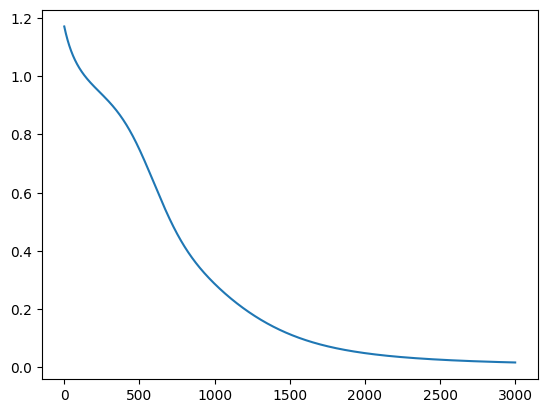

In [76]:
plt.plot(loss_hist)

In [77]:
# 8. Evaluacion y visualizacion de predicciones
with torch.no_grad():
    y_test_pred = model(X_test_tensor)
    test_loss = loss_fn(y_test_pred, y_test_tensor)
    accuracy = (y_test_pred.argmax(1) == y_test_tensor).float().mean()

print(f"Perdida en test: {test_loss.item():.4f}")
print(f"Exactitud en test: {accuracy.item()*100:.2f}%")

Perdida en test: 0.0228
Exactitud en test: 99.86%


**9. Reflexión final:**
Describe tus hallazgos y aprendizajes.

In [521]:
# Tu código aquí